In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [2]:
data_df = pd.read_csv('/content/heart_failure_clinical_records_dataset.csv')
data_df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [3]:
data_df.info()
data_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


In [4]:
data_df.isnull().sum()

,0
age,0
anaemia,0
creatinine_phosphokinase,0
diabetes,0
ejection_fraction,0
high_blood_pressure,0
platelets,0
serum_creatinine,0
serum_sodium,0
sex,0


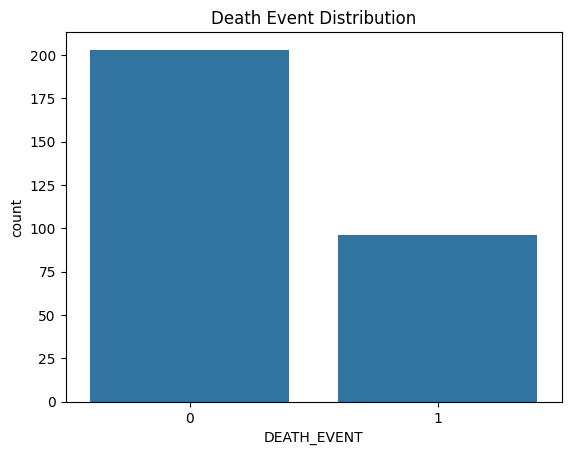

In [5]:
sns.countplot(x='DEATH_EVENT', data=data_df)
plt.title("Death Event Distribution")
plt.show()

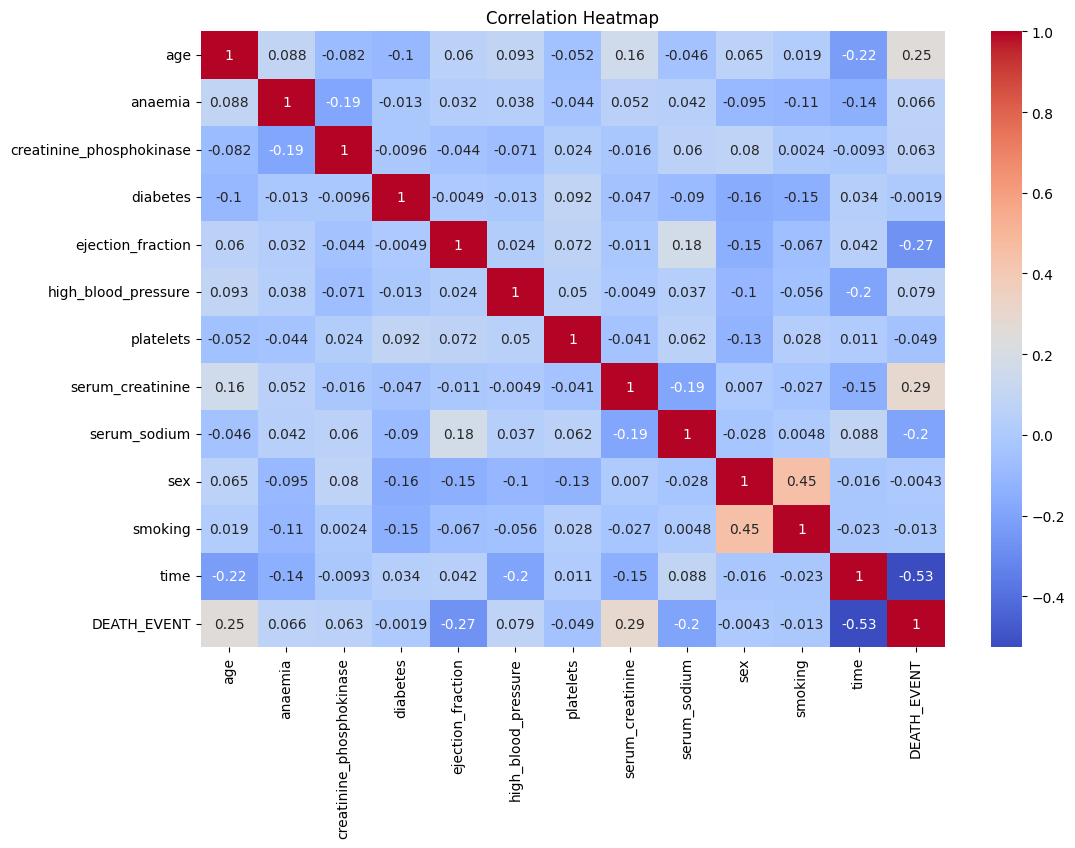

In [6]:
plt.figure(figsize=(12,8))
sns.heatmap(data_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [7]:
X = data_df.drop('DEATH_EVENT', axis=1)
y = data_df['DEATH_EVENT']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2
)

In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
svm_model = SVC(kernel='sigmoid')

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.9


In [11]:
lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8666666666666667


In [12]:
print("\nModel Comparison:")
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))


Model Comparison:
SVM Accuracy: 0.9
Logistic Regression Accuracy: 0.8666666666666667


In [14]:
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix (SVM):")
print(confusion_matrix(y_test, y_pred_svm))

print("\nClassification Report (SVM):")
print(classification_report(y_test, y_pred_svm))

Confusion Matrix (SVM):
[[41  2]
 [ 4 13]]

Classification Report (SVM):
              precision    recall  f1-score   support

           0       0.91      0.95      0.93        43
           1       0.87      0.76      0.81        17

    accuracy                           0.90        60
   macro avg       0.89      0.86      0.87        60
weighted avg       0.90      0.90      0.90        60



In [15]:
print("""
Conclusion:

This project analyzed the heart failure dataset using machine learning techniques.

Two models were implemented:
- Support Vector Machine (SVM)
- Logistic Regression

The SVM model achieved higher accuracy (~90%) compared to Logistic Regression (~86%),
indicating that the dataset likely contains non-linear relationships.

The correlation heatmap showed that features like ejection fraction, serum creatinine,
and age have strong influence on heart failure prediction.

The confusion matrix and classification report provide deeper insight into model performance.

Overall, this project demonstrates how machine learning can assist in predicting
heart failure and support healthcare decision-making.
""")


Conclusion:

This project analyzed the heart failure dataset using machine learning techniques.

Two models were implemented:
- Support Vector Machine (SVM)
- Logistic Regression

The SVM model achieved higher accuracy (~90%) compared to Logistic Regression (~86%),
indicating that the dataset likely contains non-linear relationships.

The correlation heatmap showed that features like ejection fraction, serum creatinine,
and age have strong influence on heart failure prediction.

The confusion matrix and classification report provide deeper insight into model performance.

Overall, this project demonstrates how machine learning can assist in predicting
heart failure and support healthcare decision-making.

